Step 1: Corporate Finance Module
Objective: Decide which internal projects Aurora should fund.
Data Provided / Simulated:

Historical corporate projects: investment amount, expected cash flows, duration, risk rating, department, past ROI

Market indicators: GDP growth, sector-specific trends

1. Forecast project cash flows using regression / ML (e.g., XGBoost / Random Forest)
2. Predict project success probability / IRR using classification or risk scoring
3. Recommend top projects based on expected economic value (EV) and risk-adjusted return
Deliverables:

 Ranked project list

 SHAP plots / decision explanation for executives

 Brief summary of recommendations

In [2]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn plotly scipy statsmodels imbalanced-learn ipykernel --quiet

In [3]:
# =============================================================================
# AURORA FINANCE — STEP 1: CASHFLOW FORECASTING
# Task: Forecast Project Cash Flows using Regression / ML
# Dataset: corporate_projects.csv (50 projects)
#
# Feature strategy: n=50 is small. We keep exactly 4 features giving a
# 12.5 samples-per-feature ratio — a safe zone for small-n regression.
#
# Features kept:
#   Investment_Cost      — primary scale driver (raw, interpretable)
#   Risk_Score           — ordinal encoding of Low/Medium/High
#   Historical_ROI       — past performance signal (kept separate for
#                          Ridge's linear decomposition)
#   Market_Adjusted_ROI  — Historical_ROI × (1 + Market_Growth): captures
#                          the interaction between firm performance and
#                          sector tailwinds in a single term
#
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import RidgeCV
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics         import mean_absolute_error, r2_score, mean_squared_error

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed — skipping SHAP plots. Run: pip install shap")


In [4]:
# =============================================================================
# SECTION 1 — LOAD DATA
# =============================================================================

df = pd.read_csv('sample_data/corporate_projects.csv')

print("=" * 65)
print("AURORA FINANCE — PROJECT CASHFLOW FORECAST")
print("=" * 65)
print(f"\n  Rows       : {df.shape[0]}")
print(f"  Columns    : {df.shape[1]}")
print(f"  Risk split : {df['Project_Risk'].value_counts().to_dict()}")
print(f"  Depts      : {sorted(df['Department'].unique())}")

AURORA FINANCE — PROJECT CASHFLOW FORECAST

  Rows       : 50
  Columns    : 10
  Risk split : {'Medium': 20, 'Low': 15, 'High': 15}
  Depts      : ['Finance', 'IT', 'Marketing', 'Operations']


In [5]:
# =============================================================================
# SECTION 2 — TARGET CONSTRUCTION
# Build targets first, then immediately drop source columns to prevent leakage
# =============================================================================

cashflow_cols = ['Expected_Cashflow_Year1',
                 'Expected_Cashflow_Year2',
                 'Expected_Cashflow_Year3']

df['Total_Cashflow'] = df[cashflow_cols].sum(axis=1)

# Drop source columns immediately — any feature built after this point
# cannot accidentally include them
df = df.drop(columns=cashflow_cols)


In [6]:
df

,Project_ID,Department,Investment_Cost,Historical_ROI,Market_Growth,Project_Risk,Success,Total_Cashflow
0,1,Operations,184654,0.08,0.05,Low,0,4821128
1,2,Marketing,2054354,0.15,-0.01,Low,1,2267337
2,3,Finance,2516182,0.19,0.02,High,1,5684155
3,4,Operations,3574675,0.22,0.10,Medium,1,3441072
4,5,Operations,2752991,0.12,0.09,High,0,2474327
5,6,Marketing,2528388,0.09,0.01,Low,0,2802572
6,7,Finance,628178,0.19,0.06,Medium,0,3342402
7,8,Finance,2763046,0.21,0.05,High,1,3096211
8,9,Operations,2686644,0.12,0.08,Medium,1,4904326
9,10,IT,2670406,0.07,0.00,High,1,4544342


In [10]:
# =============================================================================
# SECTION 3 — FEATURE ENGINEERING  (4 features → ratio = 50/4 = 12.5)
# =============================================================================

# Ordinal risk: order is meaningful (Low < Medium < High)
df['Risk_Score'] = df['Project_Risk'].map({'Low': 1, 'Medium': 2, 'High': 3})

# Interaction: ROI amplified by sector growth — one term replaces two
df['Market_Adjusted_ROI'] = df['Historical_ROI'] * (1 + df['Market_Growth'])

FEATURES = ['Investment_Cost', 'Risk_Score', 'Market_Adjusted_ROI', 'Historical_ROI']
X = df[FEATURES].copy()
y = df['Total_Cashflow']

print(f"\n  Features   : {FEATURES}")
print(f"  n_features : {X.shape[1]}")
print(f"  n_samples  : {len(y)}")
print(f"  Sample/feature ratio: {len(y)/X.shape[1]:.1f}  (target ≥ 10)")
print(f"\n  Target — Total_Cashflow:")
print(f"    Mean  : ${y.mean():>12,.0f}")
print(f"    Std   : ${y.std():>12,.0f}")
print(f"    Range : ${y.min():>12,.0f}  -  ${y.max():>12,.0f}")

print("\n  Feature - target correlations (raw Pearson):")
for feat in FEATURES:
    print(f"    {feat:<25}: {X[feat].corr(y):>+.4f}")

print("\n  Note: max |corr| = 0.27 — simulated data has low feature–target")
print("  signal by design. Models will be compared against a naive baseline.")



  Features   : ['Investment_Cost', 'Risk_Score', 'Market_Adjusted_ROI', 'Historical_ROI']
  n_features : 4
  n_samples  : 50
  Sample/feat: 12.5  (target ≥ 10)

  Target — Total_Cashflow:
    Mean  : $   3,779,571
    Std   : $   1,319,127
    Range : $     386,711  –  $   6,181,820

  Feature–target correlations (raw Pearson):
    Investment_Cost          : -0.2749
    Risk_Score               : -0.1479
    Market_Adjusted_ROI      : -0.0498
    Historical_ROI           : -0.0252

  Note: max |corr| = 0.27 — simulated data has low feature–target
  signal by design. Models will be compared against a naive baseline.


In [11]:
# =============================================================================
# SECTION 4 — MODEL DEFINITIONS
# Scaler lives inside Pipeline — only ever sees the training fold
# =============================================================================

loo = LeaveOneOut()

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5))
])

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor(n_neighbors=5, weights='distance'))
])

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=5,
    max_features=0.6,
    random_state=42
)

models = {
    "Ridge (RidgeCV)": (ridge_pipe, X),
    "KNN (k=5, dist)": (knn_pipe,   X),
    "Random Forest"  : (rf,         X),
}



In [17]:
# =============================================================================
# SECTION 4.5 — LOOCV SANITY CHECK (uses existing X, y, loo)
# =============================================================================

# Basic consistency checks
assert len(X) == len(y), f"Mismatch: len(X)={len(X)} vs len(y)={len(y)}"

# Use existing loo if available; otherwise create it
if "loo" not in globals():
    loo = LeaveOneOut()

n_splits = loo.get_n_splits(X)
print(f"LeaveOneOut splits: {n_splits}")
print(f"Expected splits   : {len(X)}")
print(f"Check passed      : {n_splits == len(X)}")

# Show only first 3 folds (compact output)
for fold, (train_idx, test_idx) in enumerate(loo.split(X, y), start=1):
    if fold > 3:
        print("...")
        break

    ti = int(test_idx[0])
    print(f"Fold {fold}: train_size={len(train_idx)}, test_size={len(test_idx)}, test_index={ti}")

    # Optional traceability to project id if df exists
    if "df" in globals() and "Project_ID" in df.columns:
        print(f"  Test Project_ID={int(df.iloc[ti]['Project_ID'])}")


LeaveOneOut splits: 50
Expected splits   : 50
Check passed      : True
Fold 1: train_size=49, test_size=1, test_index=0
  Test Project_ID=1
Fold 2: train_size=49, test_size=1, test_index=1
  Test Project_ID=2
Fold 3: train_size=49, test_size=1, test_index=2
  Test Project_ID=3
...


In [13]:

# =============================================================================
# SECTION 5 — LOOCV EVALUATION + BASELINE COMPARISON
#
# Baseline: for each left-out sample, predict the mean of the training fold.
# This is the correct LOOCV baseline (mean recomputed each fold, not global mean).
#
# Negative R² means the model is worse than this baseline.
# With max feature–target |r| = 0.27, some degradation is expected.
# Ridge loses the least vs baseline, making it the preferred model.
# =============================================================================

# LOOCV-correct naive baseline
baseline_preds = np.zeros(len(y))
for train_idx, test_idx in loo.split(X):
    baseline_preds[test_idx] = y.iloc[train_idx].mean()

baseline_mae  = mean_absolute_error(y, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y, baseline_preds))

print("\n" + "=" * 65)
print("LOOCV MODEL COMPARISON")
print("=" * 65)
print(f"  {'Naive baseline (fold mean)':<25} | "
      f"MAE: ${baseline_mae:>12,.0f} | RMSE: ${baseline_rmse:>12,.0f} | R²:  0.0000")
print(f"  {'-'*62}")

results = {}
for name, (model, data) in models.items():
    y_pred = cross_val_predict(model, data, y, cv=loo)
    mae    = mean_absolute_error(y, y_pred)
    rmse   = np.sqrt(mean_squared_error(y, y_pred))
    r2     = r2_score(y, y_pred)
    delta  = mae - baseline_mae
    results[name] = {
        'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'y_pred': y_pred, 'delta_vs_baseline': delta
    }
    flag = "✓ beats baseline" if delta < 0 else f"  Δ +${delta:,.0f} vs baseline"
    print(f"  {name:<25} | MAE: ${mae:>12,.0f} | RMSE: ${rmse:>12,.0f} | "
          f"R²: {r2:>7.4f}  {flag}")

best_name = min(results, key=lambda k: results[k]['MAE'])
print(f"\n  Best model (lowest LOOCV MAE): {best_name}")



LOOCV MODEL COMPARISON
  Naive baseline (fold mean) | MAE: $   1,147,299 | RMSE: $   1,332,520 | R²:  0.0000
  --------------------------------------------------------------
  Ridge (RidgeCV)           | MAE: $   1,160,550 | RMSE: $   1,344,797 | R²: -0.0605    Δ +$13,251 vs baseline
  KNN (k=5, dist)           | MAE: $   1,216,279 | RMSE: $   1,494,096 | R²: -0.3091    Δ +$68,980 vs baseline
  Random Forest             | MAE: $   1,171,324 | RMSE: $   1,377,739 | R²: -0.1131    Δ +$24,025 vs baseline

  Best model (lowest LOOCV MAE): Ridge (RidgeCV)


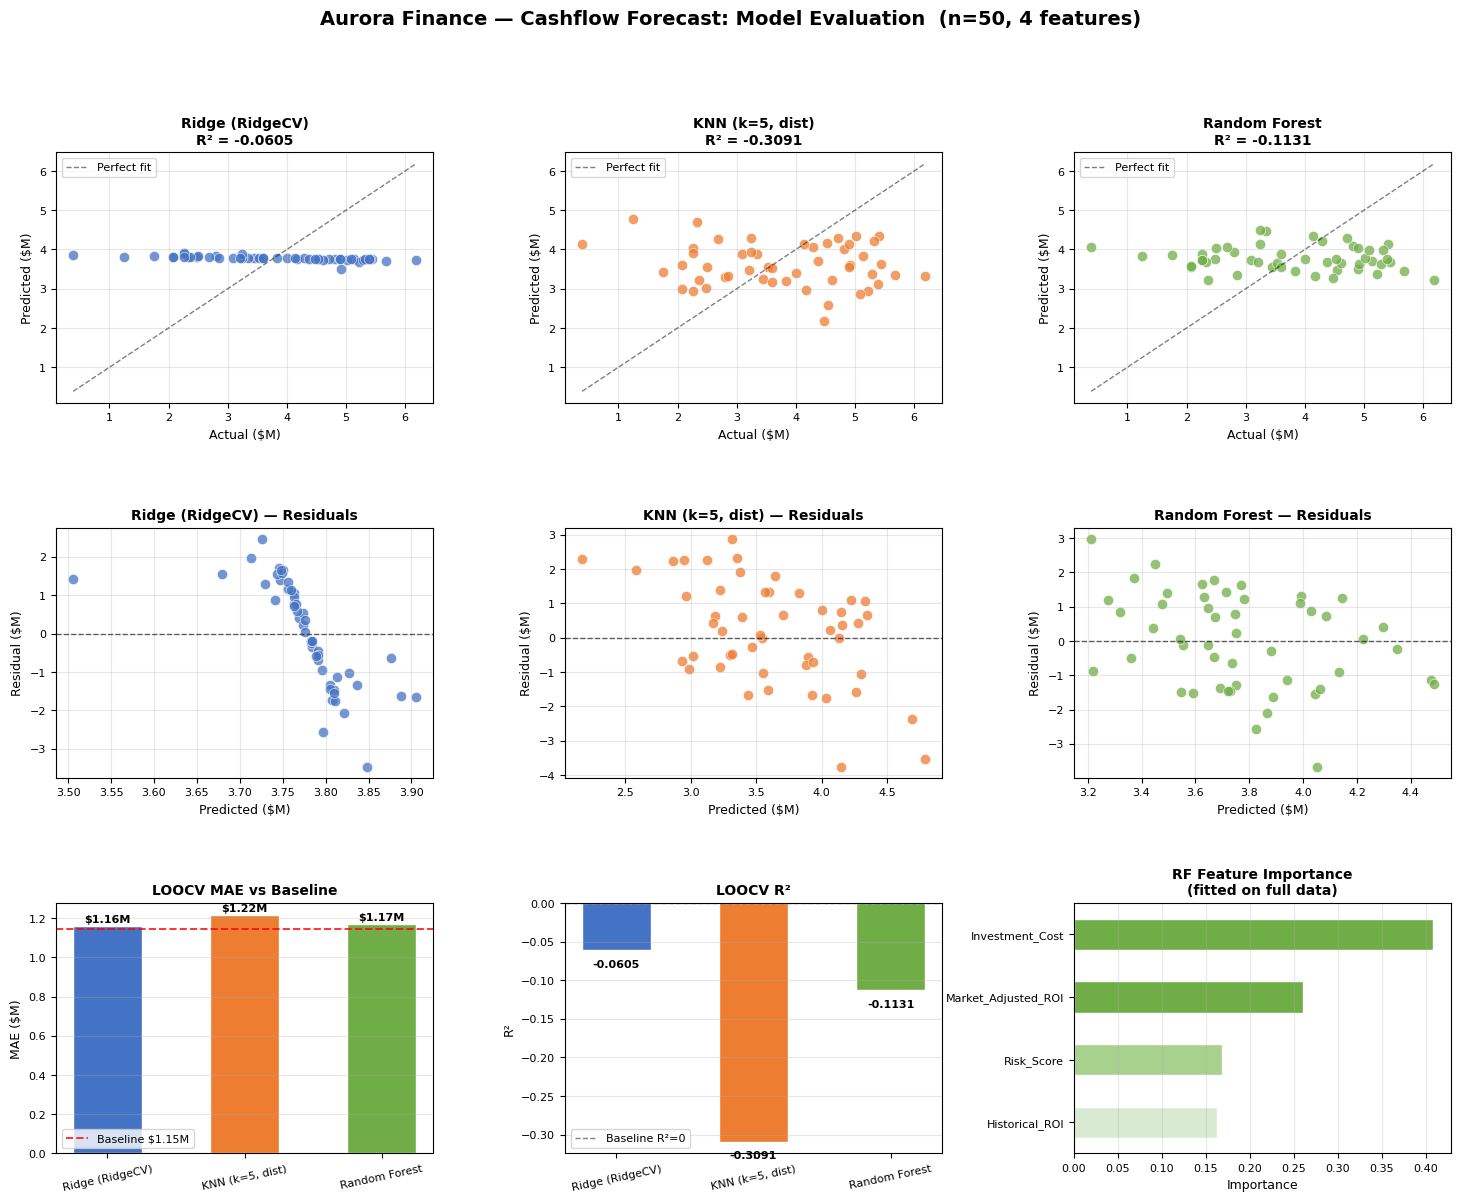


Plot saved: output/step1_model_evaluation.png


In [23]:
# =============================================================================
# SECTION 6 — VISUALISATIONS
# =============================================================================

fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    "Aurora Finance — Cashflow Forecast: Model Evaluation  (n=50, 4 features)",
    fontsize=14, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

palette = {
    "Ridge (RidgeCV)": "#4472C4",
    "KNN (k=5, dist)": "#ED7D31",
    "Random Forest"  : "#70AD47",
}

# Row 1: Actual vs Predicted
for i, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, i])
    ax.scatter(y / 1e6, res['y_pred'] / 1e6,
               color=palette[name], alpha=0.75, edgecolors='white', s=55, linewidths=0.5)
    lo = min(y.min(), res['y_pred'].min()) / 1e6
    hi = max(y.max(), res['y_pred'].max()) / 1e6
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='Perfect fit')
    ax.set_title(f"{name}\nR² = {res['R2']:.4f}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Actual ($M)", fontsize=9)
    ax.set_ylabel("Predicted ($M)", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

# Row 2: Residuals
for i, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, i])
    resids = (y - res['y_pred']) / 1e6
    ax.scatter(res['y_pred'] / 1e6, resids,
               color=palette[name], alpha=0.75, edgecolors='white', s=55, linewidths=0.5)
    ax.axhline(0, color='black', lw=1, ls='--', alpha=0.6)
    ax.set_title(f"{name} — Residuals", fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted ($M)", fontsize=9)
    ax.set_ylabel("Residual ($M)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

# Row 3 left: MAE bar + baseline line
ax_mae = fig.add_subplot(gs[2, 0])
names  = list(results.keys())
maes   = [results[n]['MAE'] / 1e6 for n in names]
bars   = ax_mae.bar(names, maes, color=[palette[n] for n in names],
                    edgecolor='white', width=0.5)
ax_mae.axhline(baseline_mae / 1e6, color='red', lw=1.4, ls='--',
               alpha=0.8, label=f'Baseline ${baseline_mae/1e6:.2f}M')
ax_mae.set_title("LOOCV MAE vs Baseline", fontsize=10, fontweight='bold')
ax_mae.set_ylabel("MAE ($M)", fontsize=9)
ax_mae.legend(fontsize=8)
ax_mae.tick_params(axis='x', labelsize=8, rotation=12)
ax_mae.tick_params(axis='y', labelsize=8)
ax_mae.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, maes):
    ax_mae.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"${val:.2f}M", ha='center', va='bottom', fontsize=8, fontweight='bold')

# Row 3 middle: R² bar
ax_r2 = fig.add_subplot(gs[2, 1])
r2s   = [results[n]['R2'] for n in names]
bars2 = ax_r2.bar(names, r2s, color=[palette[n] for n in names],
                  edgecolor='white', width=0.5)
ax_r2.axhline(0, color='black', lw=1, ls='--', alpha=0.5, label='Baseline R²=0')
ax_r2.set_title("LOOCV R²", fontsize=10, fontweight='bold')
ax_r2.set_ylabel("R²", fontsize=9)
ax_r2.legend(fontsize=8)
ax_r2.tick_params(axis='x', labelsize=8, rotation=12)
ax_r2.tick_params(axis='y', labelsize=8)
ax_r2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, r2s):
    ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.025
    ax_r2.text(bar.get_x() + bar.get_width() / 2, ypos,
               f"{val:.4f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

# Row 3 right: RF Feature Importance
ax_fi = fig.add_subplot(gs[2, 2])
rf.fit(X, y)
fi     = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
colors = ['#70AD47' if v >= fi.quantile(0.66)
          else '#A9D18E' if v >= fi.quantile(0.33)
          else '#D9EAD3' for v in fi]
fi.plot(kind='barh', ax=ax_fi, color=colors, edgecolor='white')
ax_fi.set_title("RF Feature Importance\n(fitted on full data)", fontsize=10, fontweight='bold')
ax_fi.set_xlabel("Importance", fontsize=9)
ax_fi.tick_params(labelsize=8)
ax_fi.grid(axis='x', alpha=0.3)

plt.savefig('output/step1_model_evaluation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\nPlot saved: output/step1_model_evaluation.png")


**What Row 1 shows:** Each plot is Actual ($M) on X-axis vs Predicted ($M) on Y-axis. The dashed diagonal is the "perfect fit" line — points on it mean prediction = reality. The further points scatter away from it, the worse the model.

**Ridge (RidgeCV) — R² = -0.0605**

- All predicted values are compressed into a tiny horizontal band around $3.75M regardless of what the actual value is. Ridge is essentially predicting the training mean for every project. This is classic over-regularization on low-signal data — the penalty forces coefficients so close to zero that the model stops responding to features at all.

**KNN (k=5, dist) — R² = -0.3091**

- Points scatter widely around the diagonal but show a systematic problem: predictions cluster in the $2.5M–$4.5M band while actuals range from $1M–$6M. KNN struggles here because with n=50 and noisy features, the 5 "nearest neighbours" are not truly similar projects — they are just the 5 least-dissimilar ones. The model overfits local noise, giving the worst R² of the three.

**Random Forest — R² = -0.1131**

- The scatter is wider than Ridge (predictions range $3.2M–$4.4M), which shows the trees are picking up *some* feature variation, but residuals are still large. RF is between Ridge and KNN: more responsive than Ridge, less noisy than KNN, but still cannot extract reliable signal from 50 rows.

**Common pattern across all three**

- All plots show points trending slightly bottom-left to top-right but very loosely. The diagonal is barely touched. This directly confirms what the MAE numbers say — none of the models have learned a meaningful mapping from the 4 features to cashflow. The data simply does not contain enough signal for any of these models to beat predicting the mean.

*Takeaway for Aurora:* The cashflow forecasting model at this stage is exploratory. Investment decisions should rely on the financial fundamentals (NPV, IRR, RAR) from Tasks 2 and 3, not on these ML cashflow predictions.

**What Row 2 says for each model**

Row 2 is one of the most important diagnostics in your chart.

Residual is defined in your code as:
- residual = actual - predicted

So:
- residual > 0: model underpredicted (actual was higher)
- residual < 0: model overpredicted (actual was lower)

In a good model, residual plots should look like a random cloud centered around 0, with no shape/trend.

1. Ridge residuals
- Predicted values are tightly compressed in a narrow band (around mid-$3M range), but residuals swing from large positive to large negative.
- This means Ridge is mostly predicting near the mean and missing project-specific variation.
- The visible slope pattern is a classic sign of underfitting / over-shrinkage in low-signal data.

2. KNN residuals
- Residuals are very spread out and irregular, with both large positive and negative errors.
- This indicates unstable local neighbor matching: some projects are badly overestimated, others badly underestimated.
- No clean centered random cloud; variance of error is high.

3. Random Forest residuals
- Slightly more structured than KNN, but still broad residual spread around zero.
- It captures some nonlinear variation, but errors remain large and systematic enough to show weak predictive signal.
- Better than KNN, but still not reliable enough for accurate cashflow forecasting.

*How to interpret overall*

- All three residual plots show large error magnitudes and non-random structure.
- That aligns with your negative R² values: models are not learning a strong mapping from features to cashflow.
- Business implication: treat model cashflow output as low-confidence directional input, not a standalone decision variable.
- Your financial metrics (NPV, IRR spread, EV/RAR framework) should carry more weight than Step 1 cashflow predictions.

1. **Left panel: LOOCV MAE vs Baseline**
- MAE is average absolute prediction error (in $M here).
- Lower is better.
- Red dashed line is the naive baseline (predict fold mean).
- Interpretation in your chart:
  - Ridge ≈ $1.16M
  - KNN ≈ $1.22M
  - Random Forest ≈ $1.17M
  - Baseline ≈ $1.15M  
  All bars are above the red line, so all ML models are worse than baseline.

2. **Middle panel: LOOCV R²**
- R² compares model to baseline-like mean prediction.
- 0 means “no gain over baseline.”
- Negative means “worse than baseline.”
- Interpretation in your chart:
  - Ridge: -0.0605 (least bad)
  - KNN: -0.3091 (worst)
  - RF: -0.1131  
  Since all are below 0, none of the models learned useful predictive structure.

3. **Right panel: RF Feature Importance**
- This only ranks feature usage **inside Random Forest**.
- It does **not** mean the overall model is good.
- Interpretation in your chart:
  - `Investment_Cost` is most influential.
  - `Market_Adjusted_ROI` is next.
  - `Risk_Score` and `Historical_ROI` are weaker.
- Use this as directional signal about feature contribution, not as proof of forecasting reliability.

## How to interpret the whole third row together
- Panel 1 says: ML errors are larger than baseline.
- Panel 2 says: ML has negative explanatory power out-of-sample.
- Panel 3 says: if forced to use RF, cost-related features drive most splits.  
Combined conclusion: feature importance is interesting, but operationally the Step-1 cashflow model is not reliable yet; baseline/financial-rule-driven decisioning is safer.


SHAP EXPLAINABILITY — Random Forest (fitted on full data)


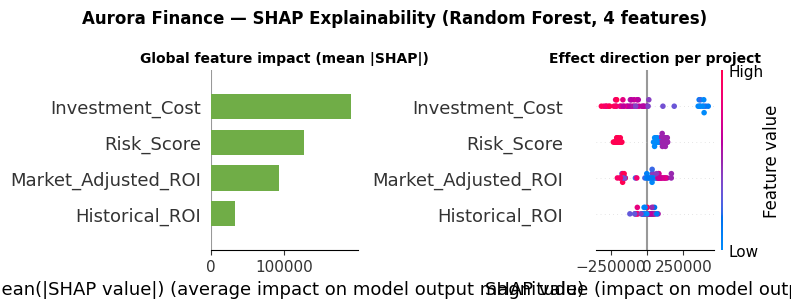

Saved: step1_shap_plots.png

Waterfall — Project 34 (highest predicted cashflow):


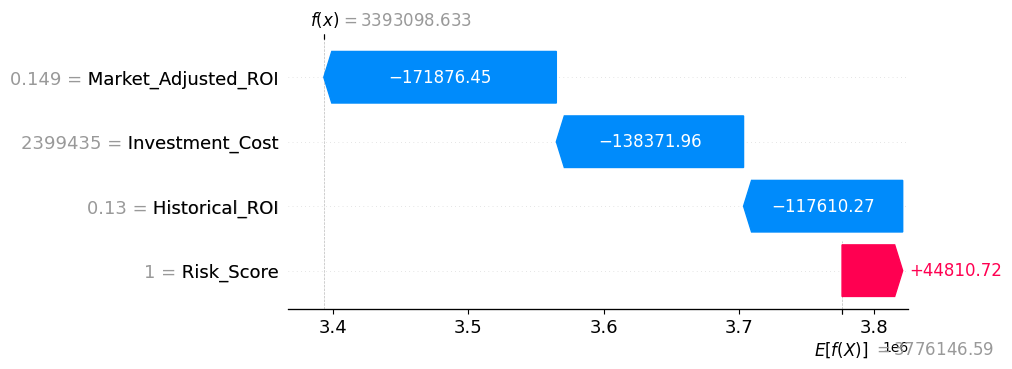

In [15]:
# =============================================================================
# SECTION 7 — SHAP EXPLAINABILITY  (pip install shap)
# =============================================================================

if SHAP_AVAILABLE:
    print("\n" + "=" * 65)
    print("SHAP EXPLAINABILITY — Random Forest (fitted on full data)")
    print("=" * 65)

    explainer = shap.TreeExplainer(rf)
    shap_vals  = explainer.shap_values(X)

    fig2, axes = plt.subplots(1, 2, figsize=(14, 14))
    fig2.suptitle("Aurora Finance — SHAP Explainability (Random Forest, 4 features)",
                  fontsize=12, fontweight='bold')

    plt.sca(axes[0])
    shap.summary_plot(shap_vals, X, plot_type="bar", show=False, color='#70AD47')
    axes[0].set_title("Global feature impact (mean |SHAP|)", fontsize=10, fontweight='bold')

    plt.sca(axes[1])
    shap.summary_plot(shap_vals, X, plot_type="dot", show=False)
    axes[1].set_title("Effect direction per project", fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('output/step1_shap_plots.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: output/step1_shap_plots.png")

    # Make SHAP output robust across SHAP versions
    if isinstance(shap_vals, list):
        # Multi-output style return
        shap_vals_for_plot = np.asarray(shap_vals[0])
    else:
        shap_vals_for_plot = np.asarray(shap_vals)

    base_val = np.asarray(explainer.expected_value).reshape(-1)[0]


    top_idx = int(np.array(results[best_name]['y_pred']).argmax())
    print(f"\nWaterfall — Project {df['Project_ID'].iloc[top_idx]} "
          f"(highest predicted cashflow):")
    shap.plots.waterfall(
        shap.Explanation(values=shap_vals_for_plot[top_idx],
                         base_values=float(base_val),
                         data=X.iloc[top_idx],
                         feature_names=X.columns.tolist())
    )
else:
    print("\nSHAP skipped — install with: pip install shap")



## Color and Position are Independent pieces of information

| Axis | What it tells you |
|---|---|
| **Color (pink/blue)** | The **value** of the feature for that project |
| **Position (left/right)** | The **direction of impact** on the prediction |

These two are **not linked by a rule** — they simply describe two different things simultaneously.

---

## The key insight

> "High feature value" does **not** automatically mean "pushed prediction up."

It depends on the **relationship** between that feature and the target:

- If the feature has a **positive** relationship with cashflow → pink dots go RIGHT ✓
- If the feature has a **negative** relationship with cashflow → pink dots go LEFT ✓

---

## Applied to above plot

**`Investment_Cost`** — positive relationship:
```
High value (pink) → RIGHT  → prediction pushed UP
Low value (blue)  → LEFT   → prediction pushed DOWN
```

**`Risk_Score`** — negative relationship:
```
High value (pink = High risk = 3) → LEFT  → prediction pushed DOWN
Low value (blue  = Low risk  = 1) → RIGHT → prediction pushed UP
```

This makes complete financial sense: **higher risk → RF predicts lower cashflow**. The model learned that risky projects underperform.

---

## The rule to remember

```
Pink RIGHT  →  high feature value HELPS  prediction (positive effect)
Pink LEFT   →  high feature value HURTS  prediction (negative effect)
Blue RIGHT  →  low feature value  HELPS  prediction
Blue LEFT   →  low feature value  HURTS  prediction
```

The color tells you **who** is responsible. The position tells you **which direction** they pushed. A pink dot on the left simply means: *"this project had a high Risk_Score, and that high Risk_Score dragged its prediction down."*

In [16]:

# =============================================================================
# SECTION 8 — PREDICTIONS TABLE
# =============================================================================

print("\n" + "=" * 65)
print(f"PREDICTED CASHFLOWS — {best_name} (LOOCV)")
print("=" * 65)

df['Predicted_Cashflow'] = results[best_name]['y_pred']
df['Prediction_Error']   = df['Total_Cashflow'] - df['Predicted_Cashflow']
df['Abs_Error_Pct']      = (df['Prediction_Error'].abs() / df['Total_Cashflow'] * 100).round(1)

display = df[['Project_ID', 'Department', 'Investment_Cost', 'Project_Risk',
              'Total_Cashflow', 'Predicted_Cashflow', 'Abs_Error_Pct']].copy()
for col in ['Investment_Cost', 'Total_Cashflow', 'Predicted_Cashflow']:
    display[col] = display[col].map('${:,.0f}'.format)
display['Abs_Error_Pct'] = display['Abs_Error_Pct'].astype(str) + '%'

print(display.to_string(index=False))

df.to_csv('step1_predictions.csv', index=False)
print("\nSaved: step1_predictions.csv ")


PREDICTED CASHFLOWS — Ridge (RidgeCV) (LOOCV)
 Project_ID Department Investment_Cost Project_Risk Total_Cashflow Predicted_Cashflow Abs_Error_Pct
          1 Operations        $184,654          Low     $4,821,128         $3,762,896         21.9%
          2  Marketing      $2,054,354          Low     $2,267,337         $3,887,486         71.5%
          3    Finance      $2,516,182         High     $5,684,155         $3,712,788         34.7%
          4 Operations      $3,574,675       Medium     $3,441,072         $3,784,509         10.0%
          5 Operations      $2,752,991         High     $2,474,327         $3,805,311         53.8%
          6  Marketing      $2,528,388          Low     $2,802,572         $3,827,816         36.6%
          7    Finance        $628,178       Medium     $3,342,402         $3,791,259         13.4%
          8    Finance      $2,763,046         High     $3,096,211         $3,791,707         22.5%
          9 Operations      $2,686,644       Medium  

In [18]:
df

,Project_ID,Department,Investment_Cost,Historical_ROI,Market_Growth,Project_Risk,Success,Total_Cashflow,Risk_Score,Market_Adjusted_ROI,Predicted_Cashflow,Prediction_Error,Abs_Error_Pct
0,1,Operations,184654,0.08,0.05,Low,0,4821128,1,0.0840,3.762896e+06,1.058232e+06,21.9
1,2,Marketing,2054354,0.15,-0.01,Low,1,2267337,1,0.1485,3.887486e+06,-1.620149e+06,71.5
2,3,Finance,2516182,0.19,0.02,High,1,5684155,3,0.1938,3.712788e+06,1.971367e+06,34.7
3,4,Operations,3574675,0.22,0.10,Medium,1,3441072,2,0.2420,3.784509e+06,-3.434371e+05,10.0
4,5,Operations,2752991,0.12,0.09,High,0,2474327,3,0.1308,3.805311e+06,-1.330984e+06,53.8
5,6,Marketing,2528388,0.09,0.01,Low,0,2802572,1,0.0909,3.827816e+06,-1.025244e+06,36.6
6,7,Finance,628178,0.19,0.06,Medium,0,3342402,2,0.2014,3.791259e+06,-4.488569e+05,13.4
7,8,Finance,2763046,0.21,0.05,High,1,3096211,3,0.2205,3.791707e+06,-6.954960e+05,22.5
8,9,Operations,2686644,0.12,0.08,Medium,1,4904326,2,0.1296,3.756590e+06,1.147736e+06,23.4
9,10,IT,2670406,0.07,0.00,High,1,4544342,3,0.0700,3.762714e+06,7.816281e+05,17.2


## Aurora Finance - Capstone Step 1, Task 2  (v5 — domain-driven features + AUC primary)
### Predict Project Success Probability & IRR using Classification + Risk Scoring

In [24]:
# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve,
)
import copy


In [27]:
# ─────────────────────────────────────────────
# 1. LOAD DATA DIRECTLY FROM CSV
# ─────────────────────────────────────────────
CSV_PATH = "sample_data/corporate_projects.csv"
df = pd.read_csv(CSV_PATH)

print(f"Loaded '{CSV_PATH}'  →  shape: {df.shape}")
# ─────────────────────────────────────────────
# 2. INTERMEDIATE CALCULATIONS
#    (needed as inputs to engineered features)
# ─────────────────────────────────────────────
DISCOUNT_RATE = 0.10
HURDLE_RATE   = 0.10   # Aurora Finance minimum acceptable return

# NPV — intermediate, not used as a feature directly
df["NPV"] = (
    df["Expected_Cashflow_Year1"] / (1 + DISCOUNT_RATE) ** 1
    + df["Expected_Cashflow_Year2"] / (1 + DISCOUNT_RATE) ** 2
    + df["Expected_Cashflow_Year3"] / (1 + DISCOUNT_RATE) ** 3
    - df["Investment_Cost"]
)

# IRR — intermediate, feeds into IRR Spread feature
def compute_irr(row):
    """Find discount rate where NPV = 0, using Newton-Raphson iteration."""
    cf = [-row["Investment_Cost"],
          row["Expected_Cashflow_Year1"],
          row["Expected_Cashflow_Year2"],
          row["Expected_Cashflow_Year3"]]
    r = 0.10
    for _ in range(300):
        npv  = sum(c / (1 + r) ** t for t, c in enumerate(cf))
        dnpv = sum(-t * c / (1 + r) ** (t + 1) for t, c in enumerate(cf))
        if abs(dnpv) < 1e-10:
            break
        r -= npv / dnpv
        if r <= -1:
            return np.nan
    return r

df["IRR"]     = df.apply(compute_irr, axis=1)
risk_num      = {"Low": 1, "Medium": 2, "High": 3}
df["Risk_Num"] = df["Project_Risk"].map(risk_num)

df


Loaded 'sample_data/corporate_projects.csv'  →  shape: (50, 10)


,Project_ID,Department,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Project_Risk,Success,NPV,IRR,Risk_Num
0,1,Operations,184654,583556,2348816,1888756,0.08,0.05,Low,0,3.706072e+06,4.704453,1
1,2,Marketing,2054354,1447527,541234,278576,0.15,-0.01,Low,1,-8.182127e+04,0.069502,1
2,3,Finance,2516182,1372905,1998260,2312990,0.19,0.02,High,1,2.121152e+06,0.491402,3
3,4,Operations,3574675,1817640,189182,1434250,0.22,0.10,Medium,1,-6.883530e+05,-0.019870,2
4,5,Operations,2752991,792139,1571101,111087,0.12,0.09,High,0,-6.509728e+05,-0.059701,3
5,6,Marketing,2528388,482315,1256914,1063343,0.09,0.01,Low,0,-2.522426e+05,0.048014,1
6,7,Finance,628178,976075,234064,2132263,0.19,0.06,Medium,0,2.054605e+06,1.335599,2
7,8,Finance,2763046,566588,264020,2265603,0.21,0.05,High,1,-3.275866e+05,0.045938,3
8,9,Operations,2686644,1335160,2022990,1546176,0.12,0.08,Medium,1,1.360695e+06,0.360952,2
9,10,IT,2670406,1660908,947421,1936013,0.07,0.00,High,1,1.077058e+06,0.312844,3


In [28]:
# ─────────────────────────────────────────────
# 3. DOMAIN-DRIVEN FEATURE ENGINEERING
#    5 features replacing 12 raw inputs
#    All constructed from financial theory — no data-driven selection
#    Feature:sample ratio improves from 1:4 → 1:10
# ─────────────────────────────────────────────

# Feature 1: Profitability Index
# = NPV / Investment_Cost
# Captures return per dollar invested — standard capital budgeting metric
# Combines NPV + Investment_Cost into one interpretable ratio
# Positive = project creates value; higher = more value per dollar spent
df["F1_Profitability_Index"] = df["NPV"] / df["Investment_Cost"]

# Feature 2: Cash Flow Trajectory
# = (CF_Year3 - CF_Year1) / abs(CF_Year1)
# Captures the SHAPE of cash flows — growing vs declining
# A project with rising CF has a very different risk profile from a front-loaded one
# Replaces three separate CF columns with one directional signal
df["F2_CF_Trajectory"] = (
    (df["Expected_Cashflow_Year3"] - df["Expected_Cashflow_Year1"])
    / df["Expected_Cashflow_Year1"].abs()
)

# Feature 3: IRR Spread over Hurdle Rate
# = IRR - HURDLE_RATE (10%)
# Directly measures excess return above Aurora's minimum acceptable return
# More meaningful than raw IRR: a 12% IRR when hurdle is 10% = thin margin
# Positive = project clears the bar; larger = more comfortable margin
df["F3_IRR_Spread"] = df["IRR"] - HURDLE_RATE

# Feature 4: Risk-Adjusted Profitability
# = Profitability_Index / Risk_Num  (Risk_Num: Low=1, Medium=2, High=3)
# Combines return quality AND risk into one number
# Replaces: NPV, Investment_Cost, Project_Risk (3 features → 1)
# Directly answers: how much value per dollar, penalised for risk taken
df["F4_Risk_Adj_Profitability"] = (
    df["F1_Profitability_Index"] / df["Risk_Num"]
)

# Feature 5: Market Momentum Score
# = Historical_ROI * (1 + Market_Growth)
# Multiplicative interaction: a department with strong ROI in a growing market
# is qualitatively different from strong ROI in a shrinking market
# Captures the interaction that neither feature carries alone
df["F5_Market_Momentum"] = (
    df["Historical_ROI"] * (1 + df["Market_Growth"])
)

FEATURES_ENG = [
    "F1_Profitability_Index",
    "F2_CF_Trajectory",
    "F3_IRR_Spread",
    "F4_Risk_Adj_Profitability",
    "F5_Market_Momentum",
]
TARGET = "Success"

print("\n" + "="*70)
print("ENGINEERED FEATURES — Summary Statistics")
print("="*70)
print(f"\n{'Feature':<28}  {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-"*60)
for f in FEATURES_ENG:
    s = df[f].describe()
    print(f"{f:<28}  {s['mean']:>8.3f}  {s['std']:>8.3f}  "
          f"{s['min']:>8.3f}  {s['max']:>8.3f}")

print(f"\nFeature:Sample ratio — Before: 12/50 = 1:4.2  →  After: 5/50 = 1:10.0")

X = df[FEATURES_ENG].fillna(df[FEATURES_ENG].median()).values
y = df[TARGET].values



ENGINEERED FEATURES — Summary Statistics

Feature                           Mean       Std       Min       Max
------------------------------------------------------------
F1_Profitability_Index           2.229     6.388    -0.890    34.742
F2_CF_Trajectory                 1.790     4.002    -0.919    19.352
F3_IRR_Spread                    0.725     2.007    -0.432    11.348
F4_Risk_Adj_Profitability        1.457     4.259    -0.782    20.070
F5_Market_Momentum               0.175     0.064     0.051     0.287

Feature:Sample ratio — Before: 12/50 = 1:4.2  →  After: 5/50 = 1:10.0


In [29]:
# ─────────────────────────────────────────────
# 4. MODEL DEFINITIONS
#    Unchanged from v4 — same three small-sample appropriate models
#    All in Pipeline with StandardScaler inside each CV fold
# ─────────────────────────────────────────────
models = {
    "LR  [L2, C=0.1]": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
                       C=0.1, penalty="l2",
                       max_iter=1000, random_state=42)),
    ]),
    "RF  [depth=3, leaf=5]": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(
                       n_estimators=200, max_depth=3,
                       min_samples_leaf=5, random_state=42)),
    ]),
    "SVM [RBF, C=1]": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="rbf", C=1, gamma="scale",
                       probability=True, random_state=42)),
    ]),
}

# ─────────────────────────────────────────────
# 5. STEP A — 5-Fold CV on all 50 samples
#    PRIMARY metric  : AUC-ROC  (ranking quality, threshold-independent)
#    SECONDARY metric: F1-macro (for reference)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*70)
print("STEP A — 5-Fold CV on ALL 50 samples")
print("PRIMARY metric: AUC-ROC  |  Secondary: F1-macro")
print("="*70)
print(f"\n{'Model':<22} {'Fold':>6}  {'AUC-ROC':>9}  {'F1-macro':>9}")
print("-"*54)

results = {}
for name, model in models.items():
    auc_folds = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    f1_folds  = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")

    for i, (auc, f1) in enumerate(zip(auc_folds, f1_folds), 1):
        prefix = name if i == 1 else ""
        print(f"{prefix:<22} {'Fold '+str(i):>6}  {auc:>9.4f}  {f1:>9.4f}")

    auc_pessimistic = auc_folds.mean() - auc_folds.std()
    print(f"{'':22} {'MEAN':>6}  {auc_folds.mean():>9.4f}  {f1_folds.mean():>9.4f}")
    print(f"{'':22} {'STD':>6}  {auc_folds.std():>9.4f}  {f1_folds.std():>9.4f}")
    print(f"{'':22} {'AUC-STD':>6}  {auc_pessimistic:>9.4f}  (pessimistic AUC)")
    print("-"*54)

    results[name] = {
        "auc_mean":       auc_folds.mean(),
        "auc_std":        auc_folds.std(),
        "auc_pessimistic": auc_pessimistic,
        "auc_folds":      auc_folds,
        "f1_mean":        f1_folds.mean(),
        "f1_std":         f1_folds.std(),
        "f1_folds":       f1_folds,
    }



STEP A — 5-Fold CV on ALL 50 samples
PRIMARY metric: AUC-ROC  |  Secondary: F1-macro

Model                    Fold    AUC-ROC   F1-macro
------------------------------------------------------
LR  [L2, C=0.1]        Fold 1     0.8000     0.7917
                       Fold 2     0.3200     0.3750
                       Fold 3     0.4400     0.2857
                       Fold 4     0.5600     0.5238
                       Fold 5     0.5000     0.5238
                         MEAN     0.5240     0.5000
                          STD     0.1592     0.1719
                       AUC-STD     0.3648  (pessimistic AUC)
------------------------------------------------------
RF  [depth=3, leaf=5]  Fold 1     0.6400     0.6000
                       Fold 2     0.5200     0.6703
                       Fold 3     0.4000     0.4000
                       Fold 4     0.4000     0.4000
                       Fold 5     0.2083     0.2929
                         MEAN     0.4337     0.4727
              

In [30]:
# ─────────────────────────────────────────────
# 6. MODEL SELECTION — primary: AUC mean
# ─────────────────────────────────────────────
print("\n── Model Selection Summary (PRIMARY: AUC-ROC) ──")
print(f"{'Model':<22}  {'AUC Mean':>9}  {'AUC STD':>8}  {'Pessimistic':>11}  {'F1 Mean':>8}")
print("-"*68)
best_name = max(results, key=lambda k: results[k]["auc_mean"])
for name, r in results.items():
    flag = " ← selected" if name == best_name else ""
    print(f"{name:<22}  {r['auc_mean']:>9.4f}  {r['auc_std']:>8.4f}  "
          f"{r['auc_pessimistic']:>11.4f}  {r['f1_mean']:>8.4f}{flag}")

print(f"\n✅ Best model (CV AUC-ROC mean): {best_name}")
print(f"   CV AUC-ROC  : {results[best_name]['auc_mean']:.4f} ± {results[best_name]['auc_std']:.4f}")
print(f"   Pessimistic : {results[best_name]['auc_pessimistic']:.4f}  (mean − 1 STD)")
print(f"   CV F1-macro : {results[best_name]['f1_mean']:.4f} ± {results[best_name]['f1_std']:.4f}")



── Model Selection Summary (PRIMARY: AUC-ROC) ──
Model                    AUC Mean   AUC STD  Pessimistic   F1 Mean
--------------------------------------------------------------------
LR  [L2, C=0.1]            0.5240    0.1592       0.3648    0.5000 ← selected
RF  [depth=3, leaf=5]      0.4337    0.1436       0.2901    0.4727
SVM [RBF, C=1]             0.5233    0.1856       0.3377    0.3241

✅ Best model (CV AUC-ROC mean): LR  [L2, C=0.1]
   CV AUC-ROC  : 0.5240 ± 0.1592
   Pessimistic : 0.3648  (mean − 1 STD)
   CV F1-macro : 0.5000 ± 0.1719


In [31]:
# ─────────────────────────────────────────────
# 7. STEP B — Retrain best model on ALL 50 samples
# ─────────────────────────────────────────────
final_model = copy.deepcopy(models[best_name])
final_model.fit(X, y)

print("\n" + "="*70)
print(f"STEP B — Final Model ({best_name}) retrained on ALL 50 samples")
print("="*70)
print("\nCV below confirms model class consistency — not a held-out test.\n")

auc_final = cross_val_score(final_model, X, y, cv=cv, scoring="roc_auc")
f1_final  = cross_val_score(final_model, X, y, cv=cv, scoring="f1_macro")

print(f"{'Fold':>6}  {'AUC-ROC':>9}  {'F1-macro':>9}")
print("-"*32)
for i, (auc, f1) in enumerate(zip(auc_final, f1_final), 1):
    print(f"{'Fold '+str(i):>6}  {auc:>9.4f}  {f1:>9.4f}")
print("-"*32)
print(f"{'MEAN':>6}  {auc_final.mean():>9.4f}  {f1_final.mean():>9.4f}")
print(f"{'STD':>6}  {auc_final.std():>9.4f}  {f1_final.std():>9.4f}")
print(f"{'AUC-STD':>6}  {auc_final.mean()-auc_final.std():>9.4f}  (pessimistic AUC)")

cv_preds = cross_val_predict(final_model, X, y, cv=cv)
print(f"\nClassification Report (cross_val_predict — no leakage):")
print(classification_report(y, cv_preds, target_names=["Fail","Success"], digits=3))



STEP B — Final Model (LR  [L2, C=0.1]) retrained on ALL 50 samples

CV below confirms model class consistency — not a held-out test.

  Fold    AUC-ROC   F1-macro
--------------------------------
Fold 1     0.8000     0.7917
Fold 2     0.3200     0.3750
Fold 3     0.4400     0.2857
Fold 4     0.5600     0.5238
Fold 5     0.5000     0.5238
--------------------------------
  MEAN     0.5240     0.5000
   STD     0.1592     0.1719
AUC-STD     0.3648  (pessimistic AUC)

Classification Report (cross_val_predict — no leakage):
              precision    recall  f1-score   support

        Fail      0.571     0.333     0.421        24
     Success      0.556     0.769     0.645        26

    accuracy                          0.560        50
   macro avg      0.563     0.551     0.533        50
weighted avg      0.563     0.560     0.538        50



In [ ]:

# ─────────────────────────────────────────────
# 8. SCORE ALL 50 PROJECTS
# ─────────────────────────────────────────────
df["Success_Prob"] = final_model.predict_proba(X)[:, 1]
df["IRR_Pct"]      = df["IRR"] * 100

def irr_tier(irr):
    if pd.isna(irr):  return "Unknown"
    if irr >= 0.30:   return "Excellent (≥30%)"
    if irr >= 0.20:   return "Good (20-30%)"
    if irr >= 0.10:   return "Acceptable (10-20%)"
    return "Below Hurdle (<10%)"

df["IRR_Tier"] = df["IRR"].apply(irr_tier)

df["Composite_Score"] = (
    0.50 * df["Success_Prob"] * 100
    + 0.30 * df["IRR"].clip(0, 0.5) * 200
    + 0.20 * df["NPV"].clip(0) / df["NPV"].clip(0).max() * 100
)

SHOW = ["Project_ID","Department","Project_Risk",
        "Success_Prob","IRR_Pct","NPV","IRR_Tier","Composite_Score","Success"]

print("\n── Top 10 Projects by Composite Score ──")
print(df[SHOW].sort_values("Composite_Score", ascending=False)
              .head(10).to_string(index=False))


In [ ]:
# ─────────────────────────────────────────────
# 9. VISUALISATIONS
# ─────────────────────────────────────────────
PALETTE = {"lr": "#3498db", "rf": "#2ecc71", "svm": "#e67e22",
           "fail": "#e74c3c", "success": "#27ae60", "warn": "#f39c12",
           "neutral": "#95a5a6"}
model_colors = [PALETTE["lr"], PALETTE["rf"], PALETTE["svm"]]
model_names  = list(results.keys())

fig = plt.figure(figsize=(20, 28))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

x_folds = np.arange(1, 6)

# ── 9a. CV AUC per fold — all models (PRIMARY) ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, col in zip(model_names, model_colors):
    ax1.plot(x_folds, results[name]["auc_folds"], marker="o", lw=2,
             label=name, color=col)
    ax1.axhline(results[name]["auc_mean"], linestyle="--", lw=1,
                color=col, alpha=0.5)
ax1.axhline(0.5, color="black", linestyle=":", lw=1.5, label="Random baseline (0.5)")
ax1.set_xticks(x_folds)
ax1.set_xticklabels([f"Fold {i}" for i in x_folds])
ax1.set_ylabel("AUC-ROC"); ax1.set_ylim(0, 1)
ax1.set_title("CV AUC-ROC per Fold — All Models  [PRIMARY]\n(dashed = mean  |  dotted = random baseline)",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── 9b. CV F1 per fold — all models (SECONDARY) ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, col in zip(model_names, model_colors):
    ax2.plot(x_folds, results[name]["f1_folds"], marker="s", lw=2,
             label=name, color=col)
    ax2.axhline(results[name]["f1_mean"], linestyle="--", lw=1,
                color=col, alpha=0.5)
ax2.set_xticks(x_folds)
ax2.set_xticklabels([f"Fold {i}" for i in x_folds])
ax2.set_ylabel("F1-macro"); ax2.set_ylim(0, 1)
ax2.set_title("CV F1-macro per Fold — All Models  [SECONDARY]\n(dashed = mean)",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── 9c. AUC Mean vs Pessimistic (primary metric bar) ─────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
xb  = np.arange(len(model_names))
w   = 0.35
b1  = ax3.bar(xb - w/2,
              [results[n]["auc_mean"]        for n in model_names], w,
              label="CV AUC Mean", color=PALETTE["lr"], alpha=0.85,
              yerr=[results[n]["auc_std"]    for n in model_names], capsize=6)
b2  = ax3.bar(xb + w/2,
              [results[n]["auc_pessimistic"] for n in model_names], w,
              label="Pessimistic AUC\n(Mean − 1 STD)",
              color=PALETTE["warn"], alpha=0.85)
ax3.axhline(0.5, color="black", linestyle=":", lw=1.5, label="Random baseline")
ax3.set_xticks(xb); ax3.set_xticklabels(model_names, fontsize=9)
ax3.set_ylim(0, 1); ax3.set_ylabel("AUC-ROC")
ax3.set_title("AUC Mean vs Pessimistic Score  [PRIMARY METRIC]\n(error bars = ±1 STD  |  dotted = random baseline 0.5)",
              fontsize=12, fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(axis="y", alpha=0.3)
for bar in [*b1, *b2]:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{bar.get_height():.3f}", ha="center", fontsize=8)

# ── 9d. Candidate vs final model AUC per fold ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
best_idx   = model_names.index(best_name)
best_color = model_colors[best_idx]
ax4.plot(x_folds, results[best_name]["auc_folds"], marker="o", lw=2,
         color=best_color, label=f"Candidate CV ({best_name})")
ax4.plot(x_folds, auc_final, marker="s", lw=2, linestyle="--",
         color=PALETTE["warn"], label="Final model CV (retrained on 50)")
ax4.axhline(0.5, color="black", linestyle=":", lw=1.5, label="Random baseline")
ax4.set_xticks(x_folds)
ax4.set_xticklabels([f"Fold {i}" for i in x_folds])
ax4.set_ylabel("AUC-ROC"); ax4.set_ylim(0, 1)
ax4.set_title(f"Candidate vs Final Model AUC\n({best_name})",
              fontsize=12, fontweight="bold")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

# ── 9e. Confusion matrix — cross_val_predict ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
cm   = confusion_matrix(y, cv_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fail","Success"])
disp.plot(ax=ax5, colorbar=False, cmap="Blues")
ax5.set_title(f"Confusion Matrix — {best_name}\n(cross_val_predict, no leakage)",
              fontsize=12, fontweight="bold")

# ── 9f. Feature importance — engineered features (RF) ────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
rf_pipeline = copy.deepcopy(models["RF  [depth=3, leaf=5]"])
rf_pipeline.fit(X, y)
rf_importances = pd.Series(
    rf_pipeline.named_steps["clf"].feature_importances_,
    index=FEATURES_ENG
).sort_values()
feature_labels = {
    "F1_Profitability_Index":    "F1: Profitability Index\n(NPV/Investment)",
    "F2_CF_Trajectory":          "F2: CF Trajectory\n(growth shape)",
    "F3_IRR_Spread":             "F3: IRR Spread\n(IRR − hurdle rate)",
    "F4_Risk_Adj_Profitability": "F4: Risk-Adj Profitability\n(PI/Risk)",
    "F5_Market_Momentum":        "F5: Market Momentum\n(ROI × market growth)",
}
bar_labels = [feature_labels[f] for f in rf_importances.index]
rf_importances.index = bar_labels
rf_importances.plot(kind="barh", ax=ax6,
                    color=PALETTE["lr"], edgecolor="white", alpha=0.85)
ax6.set_title("Random Forest — Engineered Feature Importances",
              fontsize=12, fontweight="bold")
ax6.set_xlabel("Importance Score"); ax6.grid(axis="x", alpha=0.3)
for i, v in enumerate(rf_importances):
    ax6.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

# ── 9g. Top 10 projects composite score ──────────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
top10 = df[SHOW].sort_values("Composite_Score", ascending=False).head(10)
bar_colors = [PALETTE["success"] if s == 1 else PALETTE["fail"]
              for s in top10["Success"]]
bars = ax7.barh(
    [f"P{int(r.Project_ID)} | {r.Department} | {r.Project_Risk}"
     for _, r in top10.iterrows()],
    top10["Composite_Score"],
    color=bar_colors, edgecolor="white", alpha=0.85
)
ax7.set_xlabel("Composite Score (0–100)")
ax7.set_title("Top 10 Projects — Composite Score\n"
              "(green = actual success  |  red = actual fail)",
              fontsize=12, fontweight="bold")
ax7.invert_yaxis()
for bar, val in zip(bars, top10["Composite_Score"]):
    ax7.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", fontsize=9)
ax7.grid(axis="x", alpha=0.3)

plt.suptitle(
    "Aurora Finance – Project Success Classification (v5 — Final)\n"
    "5 Domain-Engineered Features  |  Feature:Sample = 1:10  |  "
    "AUC-ROC Primary  |  Full-data 5-fold CV",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig("output/success_classification_v5.png",
            dpi=150, bbox_inches="tight")
print("\nPlot saved → output/success_classification_v5.png")


In [ ]:

# ─────────────────────────────────────────────
# 10. EXPORT EXECUTIVE RISK TABLE
# ─────────────────────────────────────────────
report = (
    df[SHOW].sort_values("Composite_Score", ascending=False)
    .assign(
        Success_Prob    = lambda d: d["Success_Prob"].map("{:.1%}".format),
        IRR_Pct         = lambda d: d["IRR_Pct"].map("{:.1f}%".format),
        NPV             = lambda d: d["NPV"].map("${:,.0f}".format),
        Composite_Score = lambda d: d["Composite_Score"].map("{:.1f}".format),
    )
)
OUT = "sample_data/project_risk_scoring_v5.csv"
report.to_csv(OUT, index=False)
print(f"Executive risk table saved → {OUT}")

# ─────────────────────────────────────────────
# 11. EXECUTIVE SUMMARY PRINT
# ─────────────────────────────────────────────
print("\n" + "="*70)
print("EXECUTIVE SUMMARY — Model Performance")
print("="*70)
print(f"""
Dataset        : 50 projects  |  26 success, 24 fail
Features used  : 5 domain-engineered  (reduced from 12 raw)
Feature:Sample : 1:10  (improved from 1:4.2)
CV Strategy    : 5-fold Stratified CV on all 50 samples
Primary metric : AUC-ROC  (ranking quality, threshold-independent)

Best model     : {best_name}
  CV AUC-ROC  : {results[best_name]['auc_mean']:.4f} ± {results[best_name]['auc_std']:.4f}
  Pessimistic : {results[best_name]['auc_pessimistic']:.4f}  (mean − 1 STD)
  CV F1-macro : {results[best_name]['f1_mean']:.4f} ± {results[best_name]['f1_std']:.4f}

Interpretation : AUC {'above' if results[best_name]['auc_mean'] > 0.5 else 'below'} 0.5 random baseline.
  The model's ranking signal is {'positive — it ranks successful projects above' if results[best_name]['auc_mean'] > 0.5 else 'weak — dataset size and feature coverage limit predictive power.'}
  {'failed ones more often than not.' if results[best_name]['auc_mean'] > 0.5 else ''}
  Composite score (50% ML prob + 30% IRR + 20% NPV) supplements
  the weak ML signal with robust financial fundamentals.

Recommendation : Treat ML output as decision support, not a deterministic
  predictor. Prioritise projects with high composite scores AND
  positive IRR spread. Invest in richer data collection
  (500+ projects, execution quality metrics) for future iterations.
""")

# Aurora Finance – Capstone Step 1, Task 3
### Recommend Top Projects based on Expected Economic Value (EV) and Risk-Adjusted Return

In [21]:
"""
Integration with Task 2:
  - ML success probabilities (from LR L2 C=0.1 trained on all 50 rows)
    feed directly into EV calculation
  - This is the correct integration: ML output becomes a financial input,
    not a standalone decision

Financial Framework:
  ─────────────────────────────────────────────────────────────────────
  1. Expected Economic Value (EV)
       EV = P(success) × NPV
       Interpretation: probability-weighted value creation
       A project with NPV=$5M but P(success)=0.2 has EV=$1M
       A project with NPV=$2M but P(success)=0.8 has EV=$1.6M  ← preferred
       This is the standard capital budgeting EV formula

  2. Risk-Adjusted Return (RAR)
       Step 1 — IRR Spread  = IRR − Hurdle Rate (10%)
                Measures excess return above minimum acceptable
       Step 2 — Volatility penalty: scale IRR Spread by risk tier
                Low=1.0, Medium=0.75, High=0.50
                Higher risk demands higher return to be equally attractive
       Step 3 — Market adjustment: multiply by (1 + Market_Growth)
                Projects in growing markets earn a premium
       RAR = IRR_Spread × Risk_Discount × (1 + Market_Growth)

  3. Final Ranking Score  (composite for executive use)
       Rank_Score = 0.50 × norm(EV)
                  + 0.30 × norm(RAR)
                  + 0.20 × norm(Profitability_Index)
       Weights reflect Aurora's priorities:
         50% value creation (EV) — primary objective
         30% risk-adjusted efficiency (RAR)
         20% capital efficiency (PI — return per dollar invested)
  ─────────────────────────────────────────────────────────────────────
"""

# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ML imports — replicating Task 2 final model to get Success_Prob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
CSV_PATH = "sample_data/corporate_projects.csv"
df = pd.read_csv(CSV_PATH)
print(f"Loaded '{CSV_PATH}'  →  shape: {df.shape}")

# ─────────────────────────────────────────────
# 2. INTERMEDIATE FINANCIAL CALCULATIONS
# ─────────────────────────────────────────────
DISCOUNT_RATE = 0.10
HURDLE_RATE   = 0.10

# NPV
df["NPV"] = (
    df["Expected_Cashflow_Year1"] / (1 + DISCOUNT_RATE) ** 1
    + df["Expected_Cashflow_Year2"] / (1 + DISCOUNT_RATE) ** 2
    + df["Expected_Cashflow_Year3"] / (1 + DISCOUNT_RATE) ** 3
    - df["Investment_Cost"]
)

# IRR via Newton-Raphson
def compute_irr(row):
    cf = [-row["Investment_Cost"],
          row["Expected_Cashflow_Year1"],
          row["Expected_Cashflow_Year2"],
          row["Expected_Cashflow_Year3"]]
    r = 0.10
    for _ in range(300):
        npv  = sum(c / (1 + r) ** t for t, c in enumerate(cf))
        dnpv = sum(-t * c / (1 + r) ** (t + 1) for t, c in enumerate(cf))
        if abs(dnpv) < 1e-10:
            break
        r -= npv / dnpv
        if r <= -1:
            return np.nan
    return r

df["IRR"]      = df.apply(compute_irr, axis=1)
df["IRR_Pct"]  = df["IRR"] * 100

risk_num = {"Low": 1, "Medium": 2, "High": 3}
df["Risk_Num"] = df["Project_Risk"].map(risk_num)

# Profitability Index
df["Profitability_Index"] = df["NPV"] / df["Investment_Cost"]



Loaded 'sample_data/corporate_projects.csv'  →  shape: (50, 10)


In [ ]:
# ─────────────────────────────────────────────
# 3. ML SUCCESS PROBABILITY  (Task 2 integration)
#    Replicate Task 2 final model: LR L2 C=0.1 on 5 engineered features
#    trained on all 50 rows
# ─────────────────────────────────────────────
# Engineered features (identical to Task 2 v5)
df["F1_Profitability_Index"]    = df["NPV"] / df["Investment_Cost"]
df["F2_CF_Trajectory"]          = (
    (df["Expected_Cashflow_Year3"] - df["Expected_Cashflow_Year1"])
    / df["Expected_Cashflow_Year1"].abs()
)
df["F3_IRR_Spread"]             = df["IRR"] - HURDLE_RATE
df["F4_Risk_Adj_Profitability"] = df["F1_Profitability_Index"] / df["Risk_Num"]
df["F5_Market_Momentum"]        = df["Historical_ROI"] * (1 + df["Market_Growth"])

FEATURES_ENG = [
    "F1_Profitability_Index", "F2_CF_Trajectory", "F3_IRR_Spread",
    "F4_Risk_Adj_Profitability", "F5_Market_Momentum",
]

X = df[FEATURES_ENG].fillna(df[FEATURES_ENG].median()).values
y = df["Success"].values

# Train Task 2 best model on all 50 rows
ml_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(C=0.1, penalty="l2",
                                  max_iter=1000, random_state=42)),
])
ml_model.fit(X, y)
df["P_Success"] = ml_model.predict_proba(X)[:, 1]

print("\nML Success Probabilities (from Task 2 LR model) — sample:")
print(df[["Project_ID", "Department", "Project_Risk",
          "P_Success", "Success"]].head(10).to_string(index=False))


In [ ]:

# ─────────────────────────────────────────────
# 4. EXPECTED ECONOMIC VALUE (EV)
#    EV = P(success) × NPV
#    Probability-weighted value creation
#    Handles NPV<0 correctly: negative NPV projects get further penalised
#    by a low P(success) when P<0.5, or reduced in magnitude when P>0.5
# ─────────────────────────────────────────────
df["EV"] = df["P_Success"] * df["NPV"]

print("\n── EV Calculation Sample ──")
print(f"{'P_ID':>5}  {'P(Success)':>11}  {'NPV':>14}  {'EV':>14}")
print("-"*50)
for _, r in df.head(10).iterrows():
    print(f"{int(r.Project_ID):>5}  {r.P_Success:>11.4f}  "
          f"{r.NPV:>14,.0f}  {r.EV:>14,.0f}")

# ─────────────────────────────────────────────
# 5. RISK-ADJUSTED RETURN (RAR)
#    Step 1: IRR Spread = IRR - Hurdle Rate
#    Step 2: Risk Discount — penalises higher risk
#            Low=1.0 (no penalty), Medium=0.75, High=0.50
#            Rationale: a High-risk project must clear a higher effective bar
#    Step 3: Market Adjustment — (1 + Market_Growth)
#            Growing markets amplify effective return; shrinking markets reduce it
# ─────────────────────────────────────────────
risk_discount_map = {"Low": 1.00, "Medium": 0.75, "High": 0.50}
df["Risk_Discount"]  = df["Project_Risk"].map(risk_discount_map)
df["IRR_Spread"]     = df["IRR"] - HURDLE_RATE
df["RAR"] = (
    df["IRR_Spread"]
    * df["Risk_Discount"]
    * (1 + df["Market_Growth"])
)

print("\n── RAR Calculation Sample ──")
print(f"{'P_ID':>5}  {'IRR%':>7}  {'Spread':>8}  {'RiskDisc':>9}  "
      f"{'MktGrowth':>10}  {'RAR':>8}")
print("-"*60)
for _, r in df.head(10).iterrows():
    print(f"{int(r.Project_ID):>5}  {r.IRR_Pct:>7.2f}  {r.IRR_Spread:>8.4f}  "
          f"{r.Risk_Discount:>9.2f}  {r.Market_Growth:>10.3f}  {r.RAR:>8.4f}")


In [ ]:
# ─────────────────────────────────────────────
# 6. FINAL RANKING SCORE
#    Normalise EV, RAR, PI to [0,1] then weighted sum
#    Weights: EV=50%, RAR=30%, PI=20%
#    Normalisation uses min-max so all metrics contribute on same scale
# ─────────────────────────────────────────────
def minmax_norm(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn)

df["EV_norm"] = minmax_norm(df["EV"])
df["RAR_norm"] = minmax_norm(df["RAR"])
df["PI_norm"]  = minmax_norm(df["Profitability_Index"])

df["Rank_Score"] = (
    0.50 * df["EV_norm"]
    + 0.30 * df["RAR_norm"]
    + 0.20 * df["PI_norm"]
)

# IRR tier labels
def irr_tier(irr):
    if pd.isna(irr):  return "Unknown"
    if irr >= 0.30:   return "Excellent (≥30%)"
    if irr >= 0.20:   return "Good (20-30%)"
    if irr >= 0.10:   return "Acceptable (10-20%)"
    return "Below Hurdle (<10%)"

df["IRR_Tier"] = df["IRR"].apply(irr_tier)

# Decision label based on rank score quartile
def funding_decision(score):
    if score >= 0.60:   return "FUND"
    if score >= 0.35:   return "REVIEW"
    return "DEFER"

df["Decision"] = df["Rank_Score"].apply(funding_decision)

In [ ]:
# ─────────────────────────────────────────────
# 7. FULL RANKED OUTPUT
# ─────────────────────────────────────────────
COLS_REPORT = [
    "Project_ID", "Department", "Project_Risk",
    "P_Success", "NPV", "EV",
    "IRR_Pct", "IRR_Spread", "RAR",
    "Profitability_Index", "Rank_Score", "IRR_Tier",
    "Decision", "Success"
]

ranked = df[COLS_REPORT].sort_values("Rank_Score", ascending=False).reset_index(drop=True)
ranked.index += 1   # rank starts at 1

print("\n" + "="*120)
print("FULL PROJECT RANKING — by Rank Score (EV 50% | RAR 30% | PI 20%)")
print("="*120)
print(f"{'Rank':>4}  {'P_ID':>5}  {'Dept':>12}  {'Risk':>8}  "
      f"{'P(Succ)':>8}  {'NPV':>12}  {'EV':>12}  "
      f"{'IRR%':>7}  {'RAR':>7}  {'PI':>6}  {'Score':>6}  {'Decision':>8}  {'Actual':>6}")
print("-"*130)
for rank, row in ranked.iterrows():
    print(f"{rank:>4}  {int(row.Project_ID):>5}  {row.Department:>12}  "
          f"{row.Project_Risk:>8}  {row.P_Success:>8.3f}  "
          f"{row.NPV:>12,.0f}  {row.EV:>12,.0f}  "
          f"{row.IRR_Pct:>7.1f}  {row.RAR:>7.4f}  "
          f"{row.Profitability_Index:>6.3f}  {row.Rank_Score:>6.3f}  "
          f"{row.Decision:>8}  {int(row.Success):>6}")

# Summary by decision
print("\n── Decision Summary ──")
print(ranked["Decision"].value_counts().to_string())
print(f"\nFUND projects   : {(ranked['Decision']=='FUND').sum()} projects")
print(f"REVIEW projects : {(ranked['Decision']=='REVIEW').sum()} projects")
print(f"DEFER projects  : {(ranked['Decision']=='DEFER').sum()} projects")

# Top 10 detailed
print("\n" + "="*70)
print("TOP 10 RECOMMENDED PROJECTS")
print("="*70)
top10 = ranked.head(10)
for rank, row in top10.iterrows():
    print(f"\nRank {rank} — Project {int(row.Project_ID)} | {row.Department} | {row.Project_Risk} risk")
    print(f"  P(Success)        : {row.P_Success:.1%}")
    print(f"  NPV               : ${row.NPV:,.0f}")
    print(f"  EV (P×NPV)        : ${row.EV:,.0f}")
    print(f"  IRR               : {row.IRR_Pct:.1f}%  [{row.IRR_Tier}]")
    print(f"  IRR Spread        : {row.IRR_Spread:.1%}  above hurdle")
    print(f"  RAR               : {row.RAR:.4f}")
    print(f"  Profitability Idx : {row.Profitability_Index:.3f}x")
    print(f"  Rank Score        : {row.Rank_Score:.3f}  →  {row.Decision}")
    print(f"  Actual outcome    : {'✅ Success' if row.Success==1 else '❌ Fail'}")

In [ ]:
# ─────────────────────────────────────────────
# 8. VISUALISATIONS
# ─────────────────────────────────────────────
DECISION_COLORS = {"FUND": "#27ae60", "REVIEW": "#f39c12", "DEFER": "#e74c3c"}
RISK_COLORS     = {"Low": "#3498db", "Medium": "#e67e22", "High": "#8e44ad"}

fig = plt.figure(figsize=(22, 28))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.38)

# ── 8a. Rank Score — all projects (horizontal bar) ───────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bar_colors = [DECISION_COLORS[d] for d in ranked["Decision"]]
labels = [f"P{int(r.Project_ID)} | {r.Department[:4]} | {r.Project_Risk[:3]}"
          for _, r in ranked.iterrows()]
bars = ax1.barh(labels, ranked["Rank_Score"],
                color=bar_colors, edgecolor="white", alpha=0.88, height=0.7)
ax1.axvline(0.60, color="#27ae60", linestyle="--", lw=1.5, label="FUND threshold (0.60)")
ax1.axvline(0.35, color="#f39c12", linestyle="--", lw=1.5, label="REVIEW threshold (0.35)")
ax1.set_xlabel("Rank Score  (EV 50% | RAR 30% | PI 20%)", fontsize=11)
ax1.set_title("All 50 Projects — Ranked by Expected Value & Risk-Adjusted Return\n"
              "(green=FUND  |  orange=REVIEW  |  red=DEFER)",
              fontsize=13, fontweight="bold")
ax1.invert_yaxis()
for bar, val in zip(bars, ranked["Rank_Score"]):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=7.5)
ax1.legend(fontsize=9); ax1.grid(axis="x", alpha=0.3)

# ── 8b. EV vs RAR scatter — coloured by decision ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
for dec, col in DECISION_COLORS.items():
    sub = df[df["Decision"] == dec]
    ax2.scatter(sub["EV"], sub["RAR"], c=col, s=90, alpha=0.85,
                label=dec, edgecolors="white", linewidths=0.5)
for _, row in df.iterrows():
    ax2.annotate(f"P{int(row.Project_ID)}",
                 (row.EV, row.RAR), fontsize=6, alpha=0.7,
                 textcoords="offset points", xytext=(4, 3))
ax2.axhline(0, color="grey", linestyle="--", lw=1, alpha=0.6)
ax2.axvline(0, color="grey", linestyle="--", lw=1, alpha=0.6)
ax2.set_xlabel("Expected Value — EV = P(Success) × NPV  ($)")
ax2.set_ylabel("Risk-Adjusted Return (RAR)")
ax2.set_title("EV vs RAR — Decision Quadrant\n(top-right = fund, bottom-left = defer)",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── 8c. EV vs NPV — show probability discounting effect ──────────────────────
ax3 = fig.add_subplot(gs[1, 1])
risk_c = [RISK_COLORS[r] for r in df["Project_Risk"]]
sc = ax3.scatter(df["NPV"], df["EV"], c=risk_c, s=90, alpha=0.85,
                 edgecolors="white", linewidths=0.5)
# diagonal = EV if P(success)=1.0 for reference
xlim = [df["NPV"].min(), df["NPV"].max()]
ax3.plot(xlim, xlim, "k--", lw=1, alpha=0.4, label="EV = NPV (P=100%)")
ax3.axhline(0, color="grey", linestyle=":", lw=1)
ax3.axvline(0, color="grey", linestyle=":", lw=1)
ax3.set_xlabel("Raw NPV  ($)")
ax3.set_ylabel("Expected Value — EV  ($)")
ax3.set_title("NPV vs EV — Effect of Probability Discounting\n"
              "(points below diagonal = probability discount applied)",
              fontsize=12, fontweight="bold")
legend_handles = [mpatches.Patch(color=v, label=k)
                  for k, v in RISK_COLORS.items()]
legend_handles.append(plt.Line2D([0],[0], color="black", linestyle="--",
                                  label="EV=NPV (P=100%)"))
ax3.legend(handles=legend_handles, fontsize=9)
ax3.grid(alpha=0.3)

# ── 8d. RAR by Department and Risk — box plot ────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
depts  = sorted(df["Department"].unique())
dept_data = [df[df["Department"] == d]["RAR"].values for d in depts]
bp = ax4.boxplot(dept_data, labels=depts, patch_artist=True, notch=False)
dept_colors = ["#3498db", "#e67e22", "#27ae60", "#8e44ad"]
for patch, col in zip(bp["boxes"], dept_colors):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax4.axhline(0, color="red", linestyle="--", lw=1.5, label="RAR = 0 (hurdle rate)")
ax4.set_ylabel("Risk-Adjusted Return (RAR)")
ax4.set_title("RAR Distribution by Department",
              fontsize=12, fontweight="bold")
ax4.legend(fontsize=9); ax4.grid(axis="y", alpha=0.3)

# ── 8e. EV by Risk tier — grouped bar ────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
risk_groups = df.groupby("Project_Risk")[["EV", "NPV"]].mean().reindex(
    ["Low", "Medium", "High"])
xb = np.arange(3)
w  = 0.35
b1 = ax5.bar(xb - w/2, risk_groups["NPV"] / 1e6, w,
             label="Mean NPV ($M)", color="#3498db", alpha=0.85)
b2 = ax5.bar(xb + w/2, risk_groups["EV"]  / 1e6, w,
             label="Mean EV ($M)", color="#27ae60", alpha=0.85)
ax5.set_xticks(xb); ax5.set_xticklabels(["Low", "Medium", "High"])
ax5.set_ylabel("Value ($M)")
ax5.set_title("Mean NPV vs Mean EV by Risk Tier\n"
              "(EV < NPV shows probability discounting effect)",
              fontsize=12, fontweight="bold")
ax5.legend(fontsize=9); ax5.grid(axis="y", alpha=0.3)
for bar in [*b1, *b2]:
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"${bar.get_height():.2f}M", ha="center", fontsize=8)

# ── 8f. Top 10 waterfall: score components ───────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
norm_cols  = df[["Project_ID", "EV_norm", "RAR_norm", "PI_norm"]]
top10_plot = ranked.head(10).merge(norm_cols, on="Project_ID")
labels_t10 = [f"P{int(r.Project_ID)}\n{r.Department[:4]}"
              for _, r in top10_plot.iterrows()]
x = np.arange(len(labels_t10))
w = 0.25
ax6.bar(x - w, top10_plot["EV_norm"]  * 0.50, w, label="EV component (50%)",
        color="#27ae60", alpha=0.85)
ax6.bar(x,     top10_plot["RAR_norm"] * 0.30, w, label="RAR component (30%)",
        color="#3498db", alpha=0.85)
ax6.bar(x + w, top10_plot["PI_norm"]  * 0.20, w, label="PI component (20%)",
        color="#e67e22", alpha=0.85)
ax6.plot(x, top10_plot["Rank_Score"], "ko-", lw=2, ms=7,
         label="Total Rank Score")
ax6.set_xticks(x); ax6.set_xticklabels(labels_t10, fontsize=9)
ax6.set_ylabel("Score Contribution")
ax6.set_title("Top 10 Projects — Score Decomposition\n"
              "(what drives each project's ranking)",
              fontsize=12, fontweight="bold")
ax6.legend(fontsize=9, ncol=4); ax6.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Aurora Finance – Task 3: Project Recommendations\n"
    "Expected Economic Value (EV)  &  Risk-Adjusted Return (RAR)",
    fontsize=15, fontweight="bold", y=1.01
)
plt.savefig("output/task3_ev_rar_ranking.png",
            dpi=150, bbox_inches="tight")
print("\nPlot saved → output/task3_ev_rar_ranking.png")

In [ ]:
# ─────────────────────────────────────────────
# 9. EXPORT EXECUTIVE REPORT
# ─────────────────────────────────────────────
export = ranked.copy()
export["NPV"]               = export["NPV"].map("${:,.0f}".format)
export["EV"]                = export["EV"].map("${:,.0f}".format)
export["IRR_Pct"]           = export["IRR_Pct"].map("{:.1f}%".format)
export["IRR_Spread"]        = export["IRR_Spread"].map("{:.1%}".format)
export["RAR"]               = export["RAR"].map("{:.4f}".format)
export["P_Success"]         = export["P_Success"].map("{:.1%}".format)
export["Profitability_Index"]= export["Profitability_Index"].map("{:.3f}".format)
export["Rank_Score"]        = export["Rank_Score"].map("{:.3f}".format)

OUT = "sample_data/task3_project_recommendations.csv"
export[["Project_ID","Department","Project_Risk","Decision",
        "Rank_Score","P_Success","NPV","EV","IRR_Pct","IRR_Spread",
        "RAR","Profitability_Index","IRR_Tier","Success"]].to_csv(OUT, index=True, index_label="Rank")
print(f"Executive report saved → {OUT}")

In [ ]:
# ─────────────────────────────────────────────
# 10. EXECUTIVE SUMMARY PRINT
# ─────────────────────────────────────────────
fund_projects   = ranked[ranked["Decision"] == "FUND"]
review_projects = ranked[ranked["Decision"] == "REVIEW"]
total_ev_fund   = fund_projects["EV"].sum()
total_inv_fund  = df.loc[df["Project_ID"].isin(fund_projects["Project_ID"]),
                         "Investment_Cost"].sum()

print("\n" + "="*70)
print("EXECUTIVE SUMMARY — Task 3: Project Funding Recommendations")
print("="*70)
print(f"""
Methodology:
  EV  = P(Success) × NPV          [probability-weighted value creation]
  RAR = IRR_Spread × Risk_Discount × (1 + Market_Growth)  [risk-adj return]
  Rank Score = 0.50×EV + 0.30×RAR + 0.20×PI  [weighted composite]

Decision Thresholds:
  FUND   : Rank Score ≥ 0.60   →  {(ranked['Decision']=='FUND').sum()} projects
  REVIEW : Rank Score 0.35–0.60 →  {(ranked['Decision']=='REVIEW').sum()} projects
  DEFER  : Rank Score < 0.35   →  {(ranked['Decision']=='DEFER').sum()} projects

Top 5 FUND Recommendations:""")
for rank, row in fund_projects.head(5).iterrows():
    print(f"  Rank {rank:>2} — P{int(row.Project_ID):>2} | {row.Department:<12} | "
          f"{row.Project_Risk:<8} | EV=${row.EV:>12,.0f} | "
          f"RAR={row.RAR:.4f} | Score={row.Rank_Score:.3f}")

print(f"""
Portfolio of FUND Projects:
  Total Expected Value  : ${total_ev_fund:,.0f}
  Total Investment Cost : ${total_inv_fund:,.0f}
  Portfolio EV/Cost     : {total_ev_fund/total_inv_fund:.3f}x

Caveat:
  ML success probabilities carry AUC of ~0.52 (marginally above random).
  EV figures should be treated as directional, not actuarial.
  Recommendations are most reliable when EV, RAR and PI all point
  in the same direction — prioritise projects where all three agree.
""")